In [ ]:
import pandas as pd
import os

file_path = os.path.join('.', 'data', 'raw')
full_path = os.path.join(file_path, '02_nav_history.csv')
file_read = pd.read_csv(full_path)
file_read['date'] = pd.to_datetime(file_read['date'])

cleaned_data = []
for a, b in file_read.groupby('amfi_code'):
    start_date = b['date'].min()
    end_date = b['date'].max()
    new_range = pd.date_range(start=start_date, end=end_date, freq='D')
    b = b.set_index('date').reindex(new_range)
    b['amfi_code'] = b['amfi_code'].ffill()
    b['nav'] = b['nav'].ffill()
    b['date'] = b.index
    cleaned_data.append(b)

new_nav_clean = pd.concat(cleaned_data)
new_nav_clean = new_nav_clean.drop_duplicates(subset=['amfi_code', 'date'])
new_nav_clean = new_nav_clean[new_nav_clean['nav'] > 0]
new_nav_clean = new_nav_clean.sort_values(by=['amfi_code', 'date'])
new_path = os.path.join('.', 'data', 'processed')
clean_nav_path = os.path.join(new_path, 'nav_history_clean.csv')
new_nav_clean.to_csv(clean_nav_path, index=False)
print('file created!')


In [12]:
import pandas as pd
import os
file_path=os.path.join('.','data','raw')
full_file_path=os.path.join(file_path,'08_investor_transactions.csv')
file_read=pd.read_csv(full_file_path)
file_read['transaction_type'].value_counts()
file_read['transaction_type']=file_read['transaction_type'].str.strip()
file_read=file_read[file_read['amount_inr']>0]
file_read['transaction_date']=pd.to_datetime(file_read['transaction_date'],dayfirst=True)
file_read['kyc_status'].value_counts()
clean_file=os.path.join('.','data','processed')
clean_file_path=os.path.join(clean_file,'clean_investor_transactions.csv')
file_read.to_csv(clean_file_path,index=False)
print('Cleaned investor transactions file')

Cleaned investor transactions file


In [8]:
import pandas as pd
import os
file_path=os.path.join('.','data','raw')
full_file_path=os.path.join(file_path,'07_scheme_performance.csv')
file_read=pd.read_csv(full_file_path)
file_read['expense_ratio_pct'].value_counts()
column=['return_1yr_pct','return_3yr_pct','return_5yr_pct']
file_read[column]=file_read[column].apply(pd.to_numeric,errors='coerce')
# for a in ['return_1yr_pct','return_3yr_pct','return_5yr_pct']:
#     file_read[a]=pd.to_numeric(file_read[a],errors='coerce')
file_read['anomaly']=False
for a in column:
    missing_value=file_read[a].isna()
    min_value=file_read[a]<-80
    max_value=file_read[a]>100
    file_read.loc[missing_value | min_value | max_value,'anomaly']= True
file_read=file_read[(file_read['expense_ratio_pct']>=0.1) & (file_read['expense_ratio_pct']<=2.5)]
file_read=file_read[file_read['expense_ratio_pct'].between(0.1,2.5)]
clean_file=os.path.join('.','data','processed')
clean_file_path=os.path.join(clean_file,'clean_scheme_transactions.csv')
file_read.to_csv(clean_file_path,index=False)
print('Cleaned scheme transactions file')

Cleaned scheme transactions file


In [15]:
import os
import numpy as np 
import pandas as pd
from sqlalchemy import create_engine, text

# ====================================================================
# STEP 1: FRESH DATABASE & TABLES CREATION
# ====================================================================
print("⏳ Step 1: Database engine aur blank tables ban rahi hain...")
engine = create_engine('sqlite:///mutual_funds.db')

with engine.connect() as conn:
    # A. dim_fund Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS dim_fund (
        amfi_code INTEGER PRIMARY KEY,
        fund_house TEXT,
        scheme_name TEXT,
        category TEXT,
        sub_category TEXT,
        plan TEXT,
        launch_date TEXT,
        benchmark TEXT,
        fund_manager TEXT,
        risk_category TEXT,
        sebi_category_code TEXT
    );
    """))
    
    # B. dim_date Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS dim_date (
        date_id TEXT PRIMARY KEY,
        day INTEGER,
        month INTEGER,
        year INTEGER,
        quarter INTEGER
    );
    """))

    # C. fact_nav Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS fact_nav (
        nav_id INTEGER PRIMARY KEY AUTOINCREMENT,
        amfi_code INTEGER,
        date_id TEXT,
        nav REAL,
        FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code),
        FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
    );
    """))

    # D. fact_transactions Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS fact_transactions (
        transaction_id TEXT PRIMARY KEY,
        investor_id TEXT,
        amfi_code INTEGER,
        transaction_date TEXT,
        transaction_type TEXT,
        amount_inr REAL,
        state TEXT,
        city TEXT,
        city_tier TEXT,
        age_group TEXT,
        gender TEXT,
        annual_income_lakh REAL,
        payment_mode TEXT,
        kyc_status TEXT,
        FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code)
    );
    """))

    # E. fact_performance Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS fact_performance (
        amfi_code INTEGER PRIMARY KEY,
        return_1yr_pct REAL,
        return_3yr_pct REAL,
        return_5yr_pct REAL,
        benchmark_3yr_pct REAL,
        alpha REAL,
        beta REAL,
        sharpe_ratio REAL,
        sortino_ratio REAL,
        std_dev_ann_pct REAL,
        max_drawdown_pct REAL,
        aum_crore REAL,
        expense_ratio_pct REAL,
        morningstar_rating INTEGER,
        risk_grade TEXT,
        is_anomaly INTEGER,
        FOREIGN KEY (amfi_code) REFERENCES dim_fund(amfi_code)
    );
    """))

    # F. fact_aum Table
    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS fact_aum (
        aum_id INTEGER PRIMARY KEY AUTOINCREMENT,
        date_id TEXT,
        fund_house TEXT,
        aum_lakh_crore REAL,
        aum_crore REAL,
        num_schemes INTEGER,
        FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
    );
    """))
    
    conn.commit()
print("🎉 Blank tables successfully ready ho gayi hain!\n")


# ====================================================================
# STEP 2: LOADING DATA FROM CSV TO SQLITE
# ====================================================================
folder_path = os.path.join("data", "raw")
print(f"⏳ Step 2: CSV files se data read karke database mein load ho raha hai...\n📍 Target Folder: {folder_path}\n")

# ---- Loading DIM_FUND ----
file_1 = os.path.join(folder_path, '01_fund_master.csv')
df_master = pd.read_csv(file_1)
dim_fund_df = df_master[[
    'amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 
    'plan', 'launch_date', 'benchmark', 'fund_manager', 'risk_category', 'sebi_category_code'
]].drop_duplicates()
dim_fund_df.to_sql('dim_fund', con=engine, if_exists='replace', index=False)
print("🔹 1. dim_fund Table Loaded!")

# ---- Loading DIM_DATE & FACT_NAV ----
file_2 = os.path.join(folder_path, '02_nav_history.csv')
df_nav = pd.read_csv(file_2)
df_nav['date'] = pd.to_datetime(df_nav['date'])

unique_dates = df_nav['date'].unique()
dim_date_df = pd.DataFrame({'date_id': unique_dates})
dim_date_df['date_id'] = dim_date_df['date_id'].dt.strftime('%Y-%m-%d')
dim_date_df['day'] = pd.to_datetime(dim_date_df['date_id']).dt.day
dim_date_df['month'] = pd.to_datetime(dim_date_df['date_id']).dt.month
dim_date_df['year'] = pd.to_datetime(dim_date_df['date_id']).dt.year
dim_date_df['quarter'] = pd.to_datetime(dim_date_df['date_id']).dt.quarter
dim_date_df.to_sql('dim_date', con=engine, if_exists='replace', index=False)
print("🔹 2. dim_date Table Loaded!")

df_nav_fact = df_nav.copy()
df_nav_fact['date_id'] = df_nav_fact['date'].dt.strftime('%Y-%m-%d')
df_nav_fact = df_nav_fact[['amfi_code', 'date_id', 'nav']]
df_nav_fact.to_sql('fact_nav', con=engine, if_exists='replace', index=False)
print("🔹 3. fact_nav Table Loaded!")

# ---- Loading FACT_TRANSACTIONS ----
file_8 = os.path.join(folder_path, '08_investor_transactions.csv')
df_trans = pd.read_csv(file_8)
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'], dayfirst=True).dt.strftime('%Y-%m-%d')
df_trans.to_sql('fact_transactions', con=engine, if_exists='replace', index=False)
print("🔹 4. fact_transactions Table Loaded!")

# ---- Loading FACT_PERFORMANCE (With Anomaly Detection) ----
file_7 = os.path.join(folder_path, '07_scheme_performance.csv')
df_perf = pd.read_csv(file_7)
df_perf['is_anomaly'] = 0
cols_to_check = ['return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct']
for col in cols_to_check:
    df_perf[col] = pd.to_numeric(df_perf[col], errors='coerce')
    is_missing = df_perf[col].isna()
    is_too_high = df_perf[col] > 100
    is_too_low = df_perf[col] < -50
    df_perf.loc[is_missing | is_too_high | is_too_low, 'is_anomaly'] = 1
df_perf.to_sql('fact_performance', con=engine, if_exists='replace', index=False)
print("🔹 5. fact_performance Table Loaded!")

# ---- Loading FACT_AUM ----
file_3 = os.path.join(folder_path, '03_aum_by_fund_house.csv')
df_aum = pd.read_csv(file_3)
df_aum['date_id'] = pd.to_datetime(df_aum['date']).dt.strftime('%Y-%m-%d')
df_aum_fact = df_aum[['date_id', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']]
df_aum_fact.to_sql('fact_aum', con=engine, if_exists='replace', index=False)
print("🔹 6. fact_aum Table Loaded!")

print("\n✅ Saara data SQLite Database mein flawlessly load ho gaya hai!\n")


# ====================================================================
# STEP 3: RUNNING THE 10 MASTER ASSIGNMENT QUERIES
# ====================================================================
print("🚀 ======================================================= 🚀")
print("📊       MASTER MUTUAL FUND ANALYTICS (10 QUERIES REPORT)     ")
print("🚀 ======================================================= 🚀\n")

with engine.connect() as conn:
    
    # QUERY 1: Top 5 States by Total Investment Amount
    print("📍 [QUERY 1] TOP 5 STATES BY TOTAL INVESTMENT AMOUNT:")
    q1 = """
        SELECT state, 
               COUNT(*) as total_transactions,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_investment_crore
        FROM fact_transactions
        WHERE transaction_type IN ('SIP', 'Lumpsum')
        GROUP BY state
        ORDER BY total_investment_crore DESC
        LIMIT 5;
    """
    print(pd.read_sql(text(q1), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 2: Top 5 Best Performing Schemes (3-Year Returns)
    print("📈 [QUERY 2] TOP 5 SCHEMES BY 3-YEAR RETURNS (%):")
    q2 = """
        SELECT f.scheme_name, f.fund_house, p.return_3yr_pct, p.risk_grade
        FROM fact_performance p
        JOIN dim_fund f ON p.amfi_code = f.amfi_code
        WHERE p.is_anomaly = 0
        ORDER BY p.return_3yr_pct DESC
        LIMIT 5;
    """
    print(pd.read_sql(text(q2), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 3: Transaction Type Split (SIP vs Lumpsum vs Redemption)
    print("💼 [QUERY 3] TRANSACTION TYPE SPLIT (VOLUME & VALUE):")
    q3 = """
        SELECT transaction_type,
               COUNT(*) as txn_count,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_amount_crore
        FROM fact_transactions
        GROUP BY transaction_type;
    """
    print(pd.read_sql(text(q3), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 4: City Tier (T30 vs B30) Investment Split
    print("🏙️ [QUERY 4] CITY TIER-WISE INVESTMENT SPLIT:")
    q4 = """
        SELECT city_tier,
               COUNT(DISTINCT investor_id) as unique_investors,
               COUNT(*) as total_transactions,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_investment_crore,
               ROUND(AVG(amount_inr), 2) as avg_ticket_size_inr
        FROM fact_transactions
        WHERE transaction_type IN ('SIP', 'Lumpsum')
        GROUP BY city_tier;
    """
    print(pd.read_sql(text(q4), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 5: Age Group-wise Investor Behavior
    print("👥 [QUERY 5] AGE GROUP-WISE INVESTMENT BEHAVIOR:")
    q5 = """
        SELECT age_group,
               COUNT(*) as total_transactions,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_investment_crore,
               ROUND(AVG(annual_income_lakh), 2) as avg_annual_income_lakh
        FROM fact_transactions
        WHERE transaction_type IN ('SIP', 'Lumpsum')
        GROUP BY age_group
        ORDER BY total_investment_crore DESC;
    """
    print(pd.read_sql(text(q5), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 6: Gender-wise Mutual Fund Investment Patterns
    print("👩‍💼 [QUERY 6] GENDER-WISE INVESTMENT PATTERNS:")
    q6 = """
        SELECT gender,
               COUNT(*) as total_transactions,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_investment_crore,
               ROUND(AVG(amount_inr), 2) as avg_investment_inr
        FROM fact_transactions
        WHERE transaction_type IN ('SIP', 'Lumpsum')
        GROUP BY gender;
    """
    print(pd.read_sql(text(q6), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 7: Risk Category wise Performance & Fund Count (PERMANENTLY FIXED WITH JOIN)
    print("⚠️ [QUERY 7] RISK CATEGORY SEGMENTATION & AVERAGE RETURNS:")
    q7 = """
        SELECT f.risk_category,
               COUNT(p.amfi_code) as total_funds,
               ROUND(AVG(p.return_1yr_pct), 2) as avg_1yr_return_pct,
               ROUND(AVG(p.return_3yr_pct), 2) as avg_3yr_return_pct
        FROM fact_performance p
        JOIN dim_fund f ON p.amfi_code = f.amfi_code
        WHERE p.is_anomaly = 0
        GROUP BY f.risk_category
        ORDER BY avg_3yr_return_pct DESC;
    """
    print(pd.read_sql(text(q7), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 8: Top 5 Fund Managers based on Average 3-Year Fund Returns
    print("👔 [QUERY 8] TOP 5 FUND MANAGERS BY AVG 3-YEAR PERFORMANCE:")
    q8 = """
        SELECT f.fund_manager,
               COUNT(DISTINCT f.amfi_code) as schemes_managed,
               ROUND(AVG(p.return_3yr_pct), 2) as avg_3yr_return_pct
        FROM fact_performance p
        JOIN dim_fund f ON p.amfi_code = f.amfi_code
        WHERE p.is_anomaly = 0 AND f.fund_manager IS NOT NULL
        GROUP BY f.fund_manager
        HAVING schemes_managed >= 1
        ORDER BY avg_3yr_return_pct DESC
        LIMIT 5;
    """
    print(pd.read_sql(text(q8), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 9: Payment Mode Preference Analysis
    print("💳 [QUERY 9] PAYMENT MODE PREFERENCE BY INVESTORS:")
    q9 = """
        SELECT payment_mode,
               COUNT(*) as transaction_count,
               ROUND(SUM(amount_inr) / 10000000, 2) as total_value_crore
        FROM fact_transactions
        GROUP BY payment_mode
        ORDER BY transaction_count DESC;
    """
    print(pd.read_sql(text(q9), conn).to_string(index=False))
    print("\n" + "-"*60 + "\n")

    # QUERY 10: KYC Status Verification Summary
    print("🔐 [QUERY 10] KYC STATUS DISTRIBUTION OF TRANSACTIONS:")
    q10 = """
        SELECT kyc_status,
               COUNT(*) as total_transactions,
               ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM fact_transactions), 2) as percentage_share
        FROM fact_transactions
        GROUP BY kyc_status;
    """
    print(pd.read_sql(text(q10), conn).to_string(index=False))

print("\n🎉 Badhai ho! Saara data workflow bina kisi rukawat ke end-to-end chal gaya.")

⏳ Step 1: Database engine aur blank tables ban rahi hain...
🎉 Blank tables successfully ready ho gayi hain!

⏳ Step 2: CSV files se data read karke database mein load ho raha hai...
📍 Target Folder: data\raw

🔹 1. dim_fund Table Loaded!
🔹 2. dim_date Table Loaded!
🔹 3. fact_nav Table Loaded!
🔹 4. fact_transactions Table Loaded!
🔹 5. fact_performance Table Loaded!
🔹 6. fact_aum Table Loaded!

✅ Saara data SQLite Database mein flawlessly load ho gaya hai!

🚀 ======================================================= 🚀
📊       MASTER MUTUAL FUND ANALYTICS (10 QUERIES REPORT)     
🚀 ======================================================= 🚀

📍 [QUERY 1] TOP 5 STATES BY TOTAL INVESTMENT AMOUNT:
         state  total_transactions  total_investment_crore
        Punjab                2513                    20.0
Madhya Pradesh                2516                    20.0
     Telangana                2328                    19.0
    Tamil Nadu                2326                    19.0
     Rajas

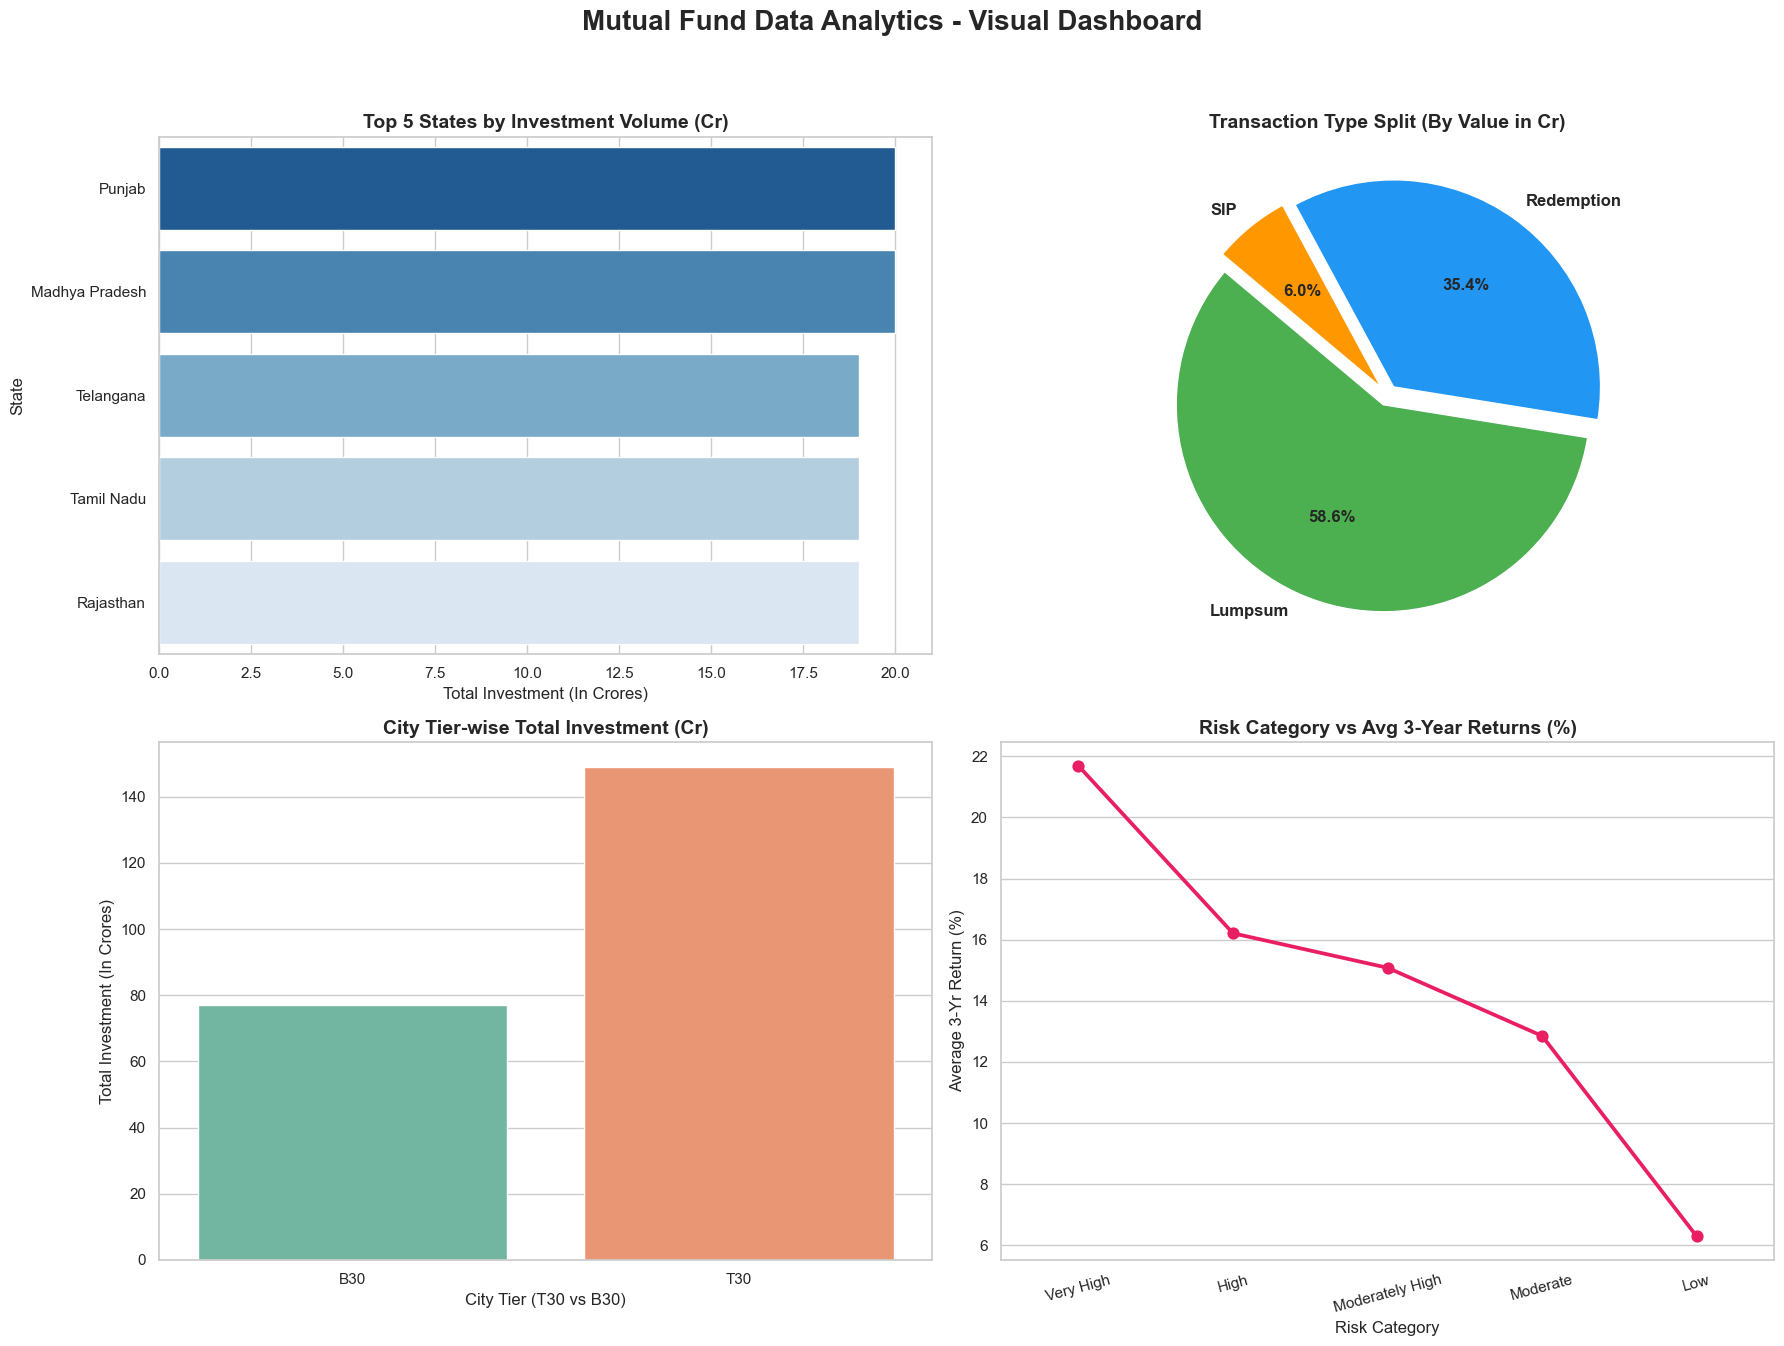

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine, text
import warnings

# Saari future aur font warnings ko hide karna taaki clean report dikhe
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Database se connect karna
engine = create_engine('sqlite:///mutual_funds.db')

# Seaborn ka clean theme set karna
sns.set_theme(style="whitegrid")

# Canvas banana (Humne titles se emojis hata diye hain taaki fonts ka jhanjhat hi khatam ho jaye)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Mutual Fund Data Analytics - Visual Dashboard', fontsize=20, fontweight='bold', y=0.96)

with engine.connect() as conn:
    # --------------------------------------------------------------------
    # CHART 1: Top 5 States by Investment (Fixed hue warning)
    # --------------------------------------------------------------------
    df_q1 = pd.read_sql(text(q1), conn)
    sns.barplot(x='total_investment_crore', y='state', data=df_q1, ax=axes[0, 0], 
                hue='state', palette='Blues_r', legend=False)
    axes[0, 0].set_title('Top 5 States by Investment Volume (Cr)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Total Investment (In Crores)')
    axes[0, 0].set_ylabel('State')

    # --------------------------------------------------------------------
    # CHART 2: Transaction Type Value Split
    # --------------------------------------------------------------------
    df_q3 = pd.read_sql(text(q3), conn)
    axes[0, 1].pie(df_q3['total_amount_crore'], labels=df_q3['transaction_type'], autopct='%1.1f%%',
                   startangle=140, colors=['#4CAF50', '#2196F3', '#FF9800'], 
                   textprops={'fontsize': 12, 'weight': 'bold'}, explode=[0.05, 0.05, 0.05])
    axes[0, 1].set_title('Transaction Type Split (By Value in Cr)', fontsize=14, fontweight='bold')

    # --------------------------------------------------------------------
    # CHART 3: City Tier-wise Investment (Fixed hue warning)
    # --------------------------------------------------------------------
    df_q4 = pd.read_sql(text(q4), conn)
    sns.barplot(x='city_tier', y='total_investment_crore', data=df_q4, ax=axes[1, 0], 
                hue='city_tier', palette='Set2', legend=False)
    axes[1, 0].set_title('City Tier-wise Total Investment (Cr)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('City Tier (T30 vs B30)')
    axes[1, 0].set_ylabel('Total Investment (In Crores)')

    # --------------------------------------------------------------------
    # CHART 4: Risk Category vs Avg 3-Year Returns
    # --------------------------------------------------------------------
    df_q7 = pd.read_sql(text(q7), conn)
    sns.pointplot(x='risk_category', y='avg_3yr_return_pct', data=df_q7, ax=axes[1, 1], color='#E91E63', markers='o', linestyles='-')
    axes[1, 1].set_title('Risk Category vs Avg 3-Year Returns (%)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Risk Category')
    axes[1, 1].set_ylabel('Average 3-Yr Return (%)')
    axes[1, 1].tick_params(axis='x', rotation=15)

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# 📘 Data Dictionary: Mutual Fund Analytics System

### 1. dim_fund (Dimension Table)
* **amfi_code** (INTEGER, PK): Unique identification code for each mutual fund scheme.
* **fund_house** (TEXT): Name of the Asset Management Company (AMC).
* **scheme_name** (TEXT): Name of the specific mutual fund scheme.
* **risk_category** (TEXT): Risk profile of the fund (e.g., High, Moderate, Low).

### 2. fact_transactions (Fact Table)
* **transaction_id** (TEXT, PK): Unique ID for each investor transaction.
* **investor_id** (TEXT): Anonymous unique identifier for the investor.
* **amount_inr** (REAL): Total transaction amount in Indian Rupees.
* **transaction_type** (TEXT): Type of investment (SIP / Lumpsum / Redemption).
* **kyc_status** (TEXT): Compliance status (Verified / Pending / Failed).

### 3. fact_performance (Fact Table)
* **amfi_code** (INTEGER, PK/FK): Mutual fund scheme identifier.
* **return_3yr_pct** (REAL): Annualized returns generated over the last 3 years.
* **is_anomaly** (INTEGER): Flag (0 or 1) indicating row validation status.